In [ ]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = list_models('vllm') + ['siglip_so400_14', 'clip_vitL14', 'eva01_vitG14_plus_2b']
# models = ['siglip_so400_14', 'siglip_so400_14_384', 'siglip_so400_14_378', 'gemma3_27b','gemma3_4b','chameleon_7b','chameleon_30b', 'paligemma2_10b_mix_224', 'paligemma2_10b_mix_448', 'paligemma2_28b_mix_224', 'paligemma2_28b_mix_448', 'paligemma2_3b_mix_224', 'paligemma2_3b_mix_448', 'paligemma_3b_224', 'paligemma_3b_448', 'paligemma_3b_mix_224', 'paligemma_3b_mix_448']

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs', download_all_precomputed=False)

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)
results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(benchmark_mappings)
from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("capability")
results["capability"] = results["benchmark_name"].map(benchmark_mappings)
sig_models = ['siglip_so400_14', 'gemma3_27b','gemma3_4b','chameleon_7b','chameleon_30b', 'paligemma2_10b_mix_224', 'paligemma2_10b_mix_448', 'paligemma2_28b_mix_224', 'paligemma2_28b_mix_448', 'paligemma2_3b_mix_224', 'paligemma2_3b_mix_448', 'paligemma_3b_224', 'paligemma_3b_448', 'paligemma_3b_mix_224', 'paligemma_3b_mix_448']
clip_models = ['clip_vitL14', 'llama_3_2_11b_vision_instruct',
       'llava_1_5_13b', 'llava_1_5_7b', 'llava_1_6_mistral_7b',
       'llava_1_6_vicuna_13b', 'llava_1_6_vicuna_7b',
       'llava_next_llama_8b']
eva_models = ['eva01_vitG14_plus_2b','aya_vision_32b', 'aya_vision_8b']

sig_results = results[results['model_name'].isin(sig_models)]
clip_results = results[results['model_name'].isin(clip_models)]
eva_results = results[results['model_name'].isin(eva_models)]

# Filter data by task types
text_classification_data = results[results['task_name'] == 'text_classification']
multi_choice_data = results[results['task_name'] == 'multi_choice_classification']

# Compute performance for each task type
text_perf = text_classification_data.groupby('model_name')['correctness'].mean() * 100
multi_choice_perf = multi_choice_data.groupby('model_name')['correctness'].mean() * 100
# Create comparison dataframe
task_comparison = pd.DataFrame({
    'model_name': text_perf.index,
    'text_classification': text_perf.values,
    'multi_choice_classification': multi_choice_perf.reindex(text_perf.index).values
})

File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/caltech101.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cars.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar10.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar100.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_count.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_distance.f
File not found:  /home/haltahan6/unibench/outpu

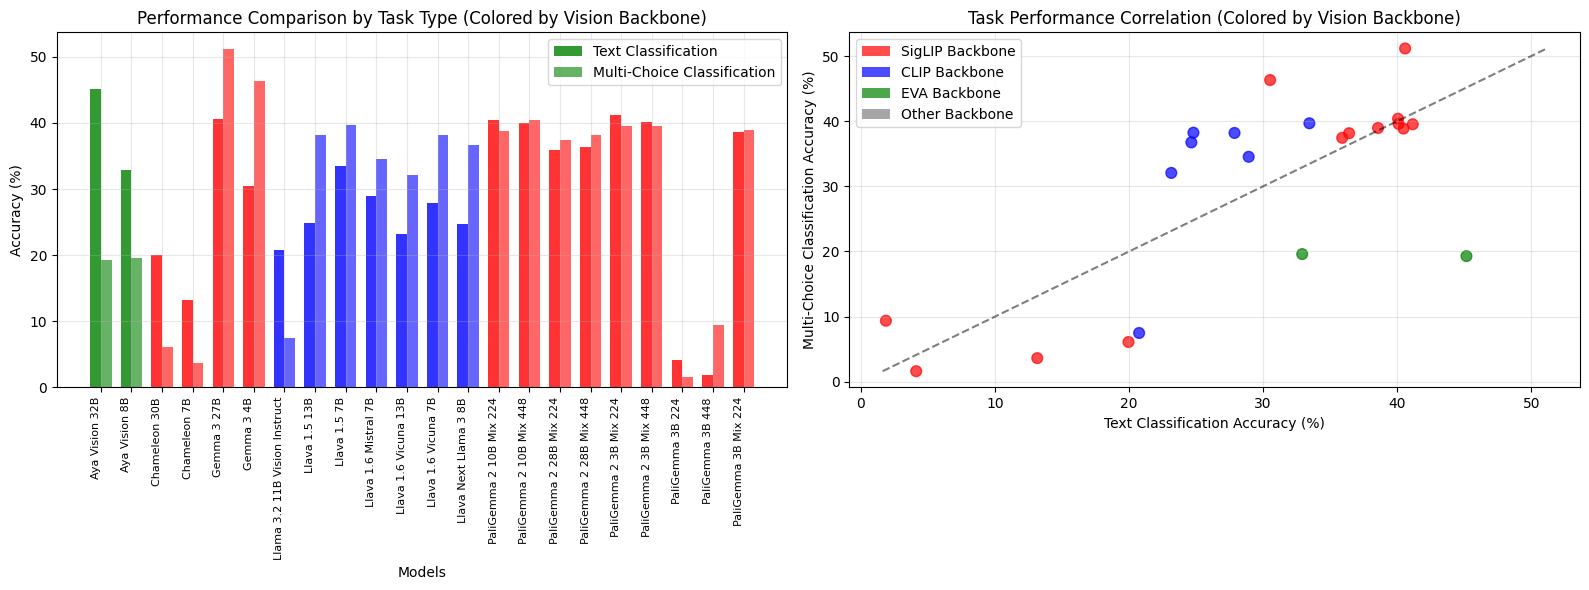


Performance Summary by Vision Backbone:

SigLIP Backbone Models:
  Text Classification - Mean: 29.5%, Std: 14.6%
  Multi-Choice Classification - Mean: 30.1%, Std: 17.8%
  Number of models: 13

CLIP Backbone Models:
  Text Classification - Mean: 26.2%, Std: 4.2%
  Multi-Choice Classification - Mean: 32.4%, Std: 11.3%
  Number of models: 7

EVA Backbone Models:
  Text Classification - Mean: 39.0%, Std: 8.7%
  Multi-Choice Classification - Mean: 19.4%, Std: 0.2%
  Number of models: 2


In [9]:
# Create color mapping based on vision backbone
def get_model_color(model_name):
    if model_name in [model_mappings.get(m, m) for m in sig_models[1:]]:  # Skip first (reference)
        return 'red'   # SigLIP models
    elif model_name in [model_mappings.get(m, m) for m in clip_models[1:]]:  # Skip first (reference)
        return 'blue'  # CLIP models
    elif model_name in [model_mappings.get(m, m) for m in eva_models[1:]]:  # Skip first (reference)
        return 'green' # EVA models
    else:
        return 'gray'  # Other models

# Apply colors to filtered data
colors = [get_model_color(model) for model in task_comparison_filtered['model_name']]

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Side-by-side comparison with backbone colors
x = range(len(task_comparison_filtered))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], task_comparison_filtered['text_classification'], 
               width, label='Text Classification', alpha=0.8, color=colors)
bars2 = ax1.bar([i + width/2 for i in x], task_comparison_filtered['multi_choice_classification'], 
               width, label='Multi-Choice Classification', alpha=0.6, color=colors)

ax1.set_xlabel('Models')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Performance Comparison by Task Type (Colored by Vision Backbone)')
ax1.set_xticks(x)
ax1.set_xticklabels(task_comparison_filtered['model_name'], rotation=90, ha='right', fontsize=8)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Scatter plot with backbone colors
scatter_colors = [get_model_color(model) for model in task_comparison_filtered['model_name']]
ax2.scatter(task_comparison_filtered['text_classification'], 
           task_comparison_filtered['multi_choice_classification'], 
           c=scatter_colors, alpha=0.7, s=60)

# Add diagonal line for reference
min_val = min(task_comparison_filtered['text_classification'].min(), 
              task_comparison_filtered['multi_choice_classification'].min())
max_val = max(task_comparison_filtered['text_classification'].max(), 
              task_comparison_filtered['multi_choice_classification'].max())
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect correlation')

ax2.set_xlabel('Text Classification Accuracy (%)')
ax2.set_ylabel('Multi-Choice Classification Accuracy (%)')
ax2.set_title('Task Performance Correlation (Colored by Vision Backbone)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Add custom legend for vision backbones with corrected colors
legend_elements = [
    Patch(facecolor='red', alpha=0.7, label='SigLIP Backbone'),
    Patch(facecolor='blue', alpha=0.7, label='CLIP Backbone'), 
    Patch(facecolor='green', alpha=0.7, label='EVA Backbone'),
    Patch(facecolor='gray', alpha=0.7, label='Other Backbone')
]
ax2.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

# Print summary by backbone with corrected colors
print("\nPerformance Summary by Vision Backbone:")
for backbone, color in [('SigLIP', 'red'), ('CLIP', 'blue'), ('EVA', 'green')]:
    backbone_models = task_comparison_filtered[
        task_comparison_filtered['model_name'].apply(get_model_color) == color
    ]
    if not backbone_models.empty:
        print(f"\n{backbone} Backbone Models:")
        print(f"  Text Classification - Mean: {backbone_models['text_classification'].mean():.1f}%, Std: {backbone_models['text_classification'].std():.1f}%")
        print(f"  Multi-Choice Classification - Mean: {backbone_models['multi_choice_classification'].mean():.1f}%, Std: {backbone_models['multi_choice_classification'].std():.1f}%")
        print(f"  Number of models: {len(backbone_models)}")
